In [1]:
import os
os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: C:\Users\Hp\farmguard-ai


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.18.0
All imports successful!


In [3]:
# All configuration in one place
CONFIG = {
    "image_size": (224, 224),
    "batch_size": 32,
    "epochs": 20,
    "learning_rate": 0.001,
    "num_classes": 6,
    "train_dir": "data/split/train",
    "val_dir": "data/split/val",
    "test_dir": "data/split/test",
    "model_save_path": "models/disease_model.h5"
}

CLASS_NAMES = [
    "Tomato Early Blight",
    "Tomato Healthy", 
    "Pepper Bacterial Spot",
    "Pepper Healthy",
    "Potato Early Blight",
    "Potato Healthy"
]

print("Configuration:")
print("="*40)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nClasses: {CLASS_NAMES}")

Configuration:
  image_size: (224, 224)
  batch_size: 32
  epochs: 20
  learning_rate: 0.001
  num_classes: 6
  train_dir: data/split/train
  val_dir: data/split/val
  test_dir: data/split/test
  model_save_path: models/disease_model.h5

Classes: ['Tomato Early Blight', 'Tomato Healthy', 'Pepper Bacterial Spot', 'Pepper Healthy', 'Potato Early Blight', 'Potato Healthy']


In [4]:
# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixel values to 0-1
    rotation_range=20,        # randomly rotate images
    width_shift_range=0.2,    # randomly shift horizontally
    height_shift_range=0.2,   # randomly shift vertically
    shear_range=0.2,          # randomly shear images
    zoom_range=0.2,           # randomly zoom in/out
    horizontal_flip=True,     # randomly flip horizontally
    fill_mode='nearest'       # fill empty pixels after transforms
)

# No augmentation for val and test — only normalize
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    CONFIG["train_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical'
)

# Load validation data
val_generator = val_test_datagen.flow_from_directory(
    CONFIG["val_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical'
)

# Load test data
test_generator = val_test_datagen.flow_from_directory(
    CONFIG["test_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"\nTraining batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")
print(f"Test batches: {len(test_generator)}")

Found 4350 images belonging to 6 classes.
Found 934 images belonging to 6 classes.
Found 934 images belonging to 6 classes.

Class indices: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___healthy': 3, 'Tomato_Early_blight': 4, 'Tomato_healthy': 5}

Training batches: 136
Validation batches: 30
Test batches: 30


In [5]:
from tensorflow.keras.regularizers import l2

# Load MobileNetV2 pretrained on ImageNet
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers
base_model.trainable = False

# Build our custom top layers with L2 regularization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
output = Dense(CONFIG["num_classes"], activation='softmax', kernel_regularizer=l2(0.01))(x)

# Create final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=CONFIG["learning_rate"]),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print(f"Total layers: {len(model.layers)}")
print(f"Trainable layers: {len([l for l in model.layers if l.trainable])}")
print(f"Non-trainable layers: {len([l for l in model.layers if not l.trainable])}")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 284s 30us/step
Total layers: 157
Trainable layers: 3
Non-trainable layers: 154


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape       ┃    Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer          │ (None, 224, 224,   │          0 │ -                  │
│ (InputLayer)         │ 3)                 │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ Conv1 (Conv2D)       │ (None, 112, 112,   │        864 │ input_layer[0][0]  │
│                      │ 32)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ bn_Conv1             │ (None, 112, 112,   │        128 │ Conv1[0][0]        │
│ (BatchNormalization) │ 32)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ Conv1_relu (ReLU)    │ (None, 112, 112,   │          0 │ bn_Conv1[0][0]     │
│                      │ 32)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ expanded_conv_depth… │ (None, 112, 112,   │        288 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)    │ 32)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ expanded_conv_depth… │ (None, 112, 112,   │        128 │ expanded_conv_dep… │
│ (BatchNormalization) │ 32)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ expanded_conv_depth… │ (None, 112, 112,   │          0 │ expanded_conv_dep… │
│ (ReLU)               │ 32)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ expanded_conv_proje… │ (None, 112, 112,   │        512 │ expanded_conv_dep… │
│ (Conv2D)             │ 16)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ expanded_conv_proje… │ (None, 112, 112,   │         64 │ expanded_conv_pro… │
│ (BatchNormalization) │ 16)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block_1_expand       │ (None, 112, 112,   │      1,536 │ expanded_conv_pro… │
│ (Conv2D)             │ 96)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block_1_expand_BN    │ (None, 112, 112,   │        384 │ block_1_expand[0]… │
│ (BatchNormalization) │ 96)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block_1_expand_relu  │ (None, 112, 112,   │          0 │ block_1_expand_BN… │
│ (ReLU)               │ 96)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block_1_pad          │ (None, 113, 113,   │          0 │ block_1_expand_re… │
│ (ZeroPadding2D)      │ 96)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block_1_depthwise    │ (None, 56, 56, 96) │        864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)    │                    │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block_1_depthwise_BN │ (None, 56, 56, 96) │        384 │ block_1_depthwise… │
│ (BatchNormalization) │                    │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block_1_depthwise_r… │ (None, 56, 56, 96) │          0 │ block_1_depthwise… │
│ (ReLU)               │                    │            │                    │


 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights to handle Potato Healthy imbalance
labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
class_labels = list(train_generator.class_indices.keys())
for idx, weight in class_weight_dict.items():
    print(f"  {class_labels[idx]}: {weight:.4f}")

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CONFIG["model_save_path"],
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\nCallbacks configured!")
print("- EarlyStopping: stops if val_loss doesn't improve for 5 epochs")
print("- ModelCheckpoint: saves best model automatically")

Class weights:
  Pepper__bell___Bacterial_spot: 1.0402
  Pepper__bell___healthy: 0.7012
  Potato___Early_blight: 1.0357
  Potato___healthy: 6.8396
  Tomato_Early_blight: 1.0357
  Tomato_healthy: 0.6514

Callbacks configured!
- EarlyStopping: stops if val_loss doesn't improve for 5 epochs
- ModelCheckpoint: saves best model automatically


In [7]:
# Train the model
print("Starting training...")
print("="*50)

history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Starting training...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7882 - loss: 2.4055
Epoch 1: val_accuracy improved from None to 0.96146, saving model to models/disease_model.h5



Epoch 1: finished saving model to models/disease_model.h5
136/136 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.8871 - loss: 1.6866 - val_accuracy: 0.9615 - val_loss: 0.9122
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.9403 - loss: 0.8467
Epoch 2: val_accuracy improved from 0.96146 to 0.96681, saving model to models/disease_model.h5



Epoch 2: finished saving model to models/disease_model.h5
136/136 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9469 - loss: 0.7391 - val_accuracy: 0.9668 - val_loss: 0.5682
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.9617 - loss: 0.5182
Epoch 3: val_accuracy improved from 0.96681 to 0.97002, saving model to models/disease_model.h5



Epoch 3: finished saving model to models/disease_model.h5
136/136 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9602 - loss: 0.4881 - val_accuracy: 0.9700 - val_loss: 0.4151
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.9618 - loss: 0.4038
Epoch 4: val_accuracy improved from 0.97002 to 0.97537, saving model to models/disease_model.h5



Epoch 4: finished saving model to models/disease_model.h5
136/136 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9632 - loss: 0.3844 - val_accuracy: 0.9754 - val_loss: 0.3458
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.9553 - loss: 0.3680
Epoch 5: val_accuracy did not improve from 0.97537
136/136 ━━━━━━━━━━━━━━━━━━━━ 135s 996ms/step - accuracy: 0.9526 - loss: 0.3718 - val_accuracy: 0.9732 - val_loss: 0.3216
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.9674 - loss: 0.3165
Epoch 6: val_accuracy improved from 0.97537 to 0.97966, saving model to models/disease_model.h5



Epoch 6: finished saving model to models/disease_model.h5
136/136 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9605 - loss: 0.3238 - val_accuracy: 0.9797 - val_loss: 0.3029
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.9647 - loss: 0.2930
Epoch 7: val_accuracy did not improve from 0.97966
136/136 ━━━━━━━━━━━━━━━━━━━━ 133s 973ms/step - accuracy: 0.9575 - loss: 0.3031 - val_accuracy: 0.9572 - val_loss: 0.3162
Epoch 8/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9634 - loss: 0.2903
Epoch 8: val_accuracy did not improve from 0.97966
136/136 ━━━━━━━━━━━━━━━━━━━━ 134s 983ms/step - accuracy: 0.9637 - loss: 0.2845 - val_accuracy: 0.9443 - val_loss: 0.3420
Epoch 9/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - accuracy: 0.9589 - loss: 0.2909
Epoch 9: val_accuracy did not improve from 0.97966
136/136 ━━━━━━━━━━━━━━━━━━━━ 134s 987ms/step - accuracy: 0.9609 - loss: 0.3010 - val_accuracy: 0.9668 - val_loss: 0.2974
Epoch 10/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s

In [8]:
# Final evaluation on test set
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nFinal Results:")
print("="*40)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

Evaluating on test set...
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 798ms/step - accuracy: 0.9690 - loss: 0.2703

Final Results:
Test Accuracy: 96.90%
Test Loss:     0.2703


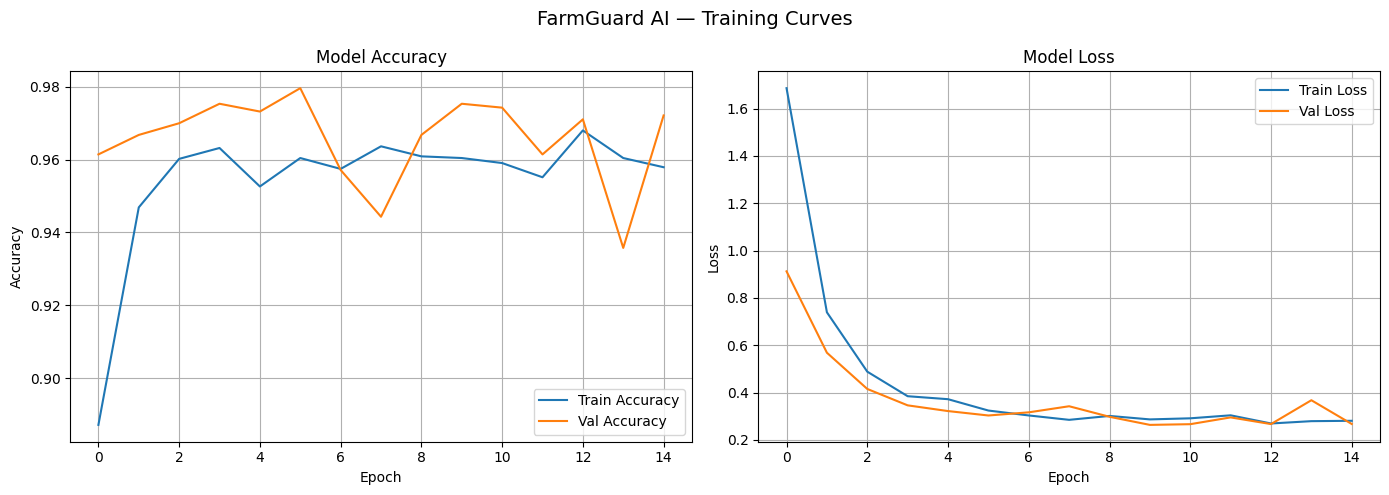

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('FarmGuard AI — Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 756ms/step


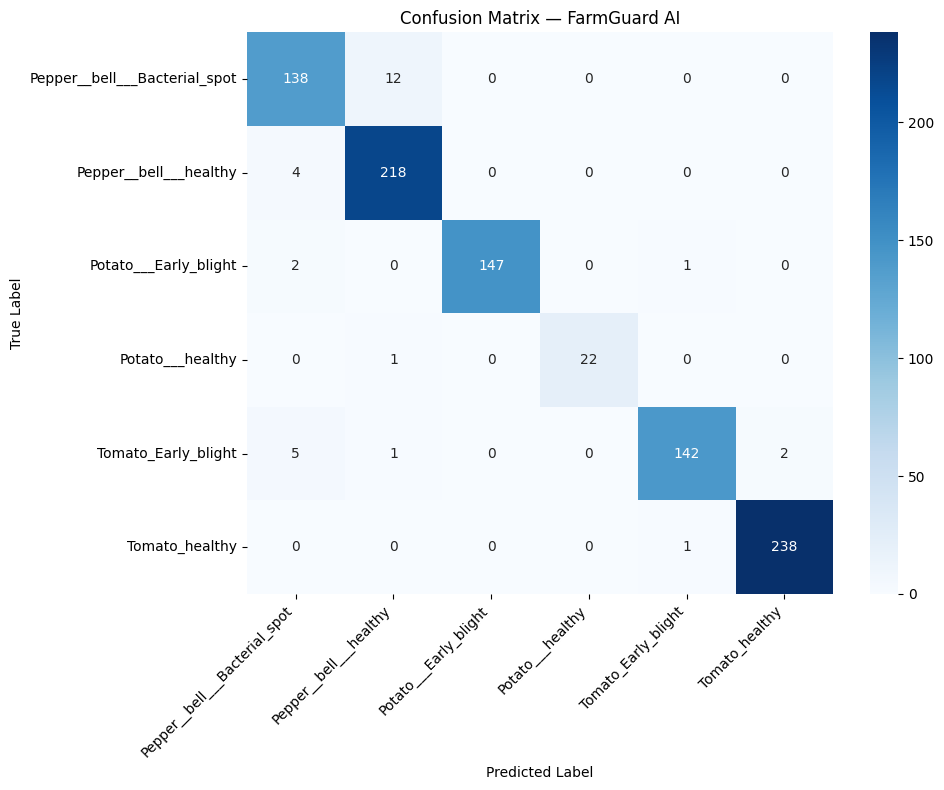


Classification Report:
                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       0.93      0.92      0.92       150
       Pepper__bell___healthy       0.94      0.98      0.96       222
        Potato___Early_blight       1.00      0.98      0.99       150
             Potato___healthy       1.00      0.96      0.98        23
          Tomato_Early_blight       0.99      0.95      0.97       150
               Tomato_healthy       0.99      1.00      0.99       239

                     accuracy                           0.97       934
                    macro avg       0.97      0.96      0.97       934
                 weighted avg       0.97      0.97      0.97       934



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

# Get predictions
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Plot confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix — FarmGuard AI')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))